In [20]:
# Install required packages
%pip install torch pandas numpy scikit-learn tqdm matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\vassa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load and Prepare Data

In [22]:
# Define paths
LOW_LEVEL_PATH = '../../low_level_features/dataset/all_low_level_features_merged.csv'
HIGH_LEVEL_PATH = '../../high_level_features/dataset/all_captures_dataset.csv'

# Load datasets
print("Loading low-level features...")
low_level_df = pd.read_csv(LOW_LEVEL_PATH)
print(f"Low-level data shape: {low_level_df.shape}")

print("\nLoading high-level features...")
high_level_df = pd.read_csv(HIGH_LEVEL_PATH)
print(f"High-level data shape: {high_level_df.shape}")

# Create mapping from capture_id/file_id to implementation
id_to_implementation = dict(zip(high_level_df['file_id'], high_level_df['implementation']))
print(f"\nUnique implementations: {high_level_df['implementation'].unique()}")
print(f"Implementation counts:\n{high_level_df['implementation'].value_counts()}")

Loading low-level features...
Low-level data shape: (261196, 26)

Loading high-level features...
High-level data shape: (11911, 57)

Unique implementations: ['aioquic' 'nginx' 'quicgo' 'quiche']
Implementation counts:
quiche     3170
quicgo     2999
nginx      2992
aioquic    2750
Name: implementation, dtype: int64


In [23]:
# Verify mapping - get unique capture_ids that have implementation labels
valid_capture_ids = set(low_level_df['capture_id'].unique()) & set(high_level_df['file_id'].unique())
print(f"Valid capture IDs with implementation labels: {len(valid_capture_ids)}")

# Filter low_level_df to only include sequences with valid implementation labels
low_level_df = low_level_df[low_level_df['capture_id'].isin(valid_capture_ids)]
print(f"Filtered low-level data shape: {low_level_df.shape}")

Valid capture IDs with implementation labels: 11911
Filtered low-level data shape: (261196, 26)


## 2. Dataset Class for Sequential Data

In [24]:
class LowLevelSequenceDataset(Dataset):
    """
    Dataset class for loading low-level packet sequences.
    Each sequence represents a QUIC connection capture.
    """
    def __init__(self, low_level_df, id_to_implementation, capture_ids, scaler=None, max_seq_len=100):
        """
        Args:
            low_level_df: DataFrame with low-level packet features
            id_to_implementation: Dict mapping capture_id to implementation
            capture_ids: List of capture_ids to include in this dataset
            scaler: Pre-fitted scaler (for test set) or None (for train set)
            max_seq_len: Maximum sequence length (truncate/pad to this length)
        """
        self.low_level_df = low_level_df
        self.id_to_implementation = id_to_implementation
        self.capture_ids = capture_ids
        self.max_seq_len = max_seq_len
        
        # Features to use (exclude frame_number and capture_id)
        self.feature_columns = [
            'delta_time', 'packet_length', 'packet_direction', 'header_form',
            'count_initial', 'count_0rtt', 'count_handshake', 'count_1rtt',
            'count_retry', 'count_vn', 'count_ack', 'count_padding',
            'count_connection_close', 'count_path_challenge', 'count_path_response',
            'count_new_connection_id', 'count_retire_cid', 'count_ping',
            'count_crypto', 'count_handshake_done', 'http3_stream_count',
            'http3_fin_count', 'stream_length', 'stream_type_count'
        ]
        
        # Encode labels
        self.label_encoder = LabelEncoder()
        all_implementations = list(set(id_to_implementation.values()))
        self.label_encoder.fit(all_implementations)
        
        # Fit or use provided scaler
        if scaler is None:
            self.scaler = MinMaxScaler()
            # Fit scaler on all features for training capture_ids
            train_data = self.low_level_df[self.low_level_df['capture_id'].isin(capture_ids)]
            self.scaler.fit(train_data[self.feature_columns].values)
        else:
            self.scaler = scaler
    
    def __len__(self):
        return len(self.capture_ids)
    
    def __getitem__(self, idx):
        capture_id = self.capture_ids[idx]
        
        # Get sequence for this capture
        sequence_df = self.low_level_df[self.low_level_df['capture_id'] == capture_id]
        sequence_df = sequence_df[self.feature_columns]
        
        # Scale features
        scaled_sequence = self.scaler.transform(sequence_df.values)
        
        # Get label
        implementation = self.id_to_implementation[capture_id]
        label = self.label_encoder.transform([implementation])[0]
        
        return {
            'sequence': torch.FloatTensor(scaled_sequence),
            'label': torch.LongTensor([label])[0],
            'capture_id': capture_id
        }

In [25]:
def collate_fn(batch):
    """
    Custom collate function to handle variable-length sequences.
    Pads sequences to the maximum length in the batch.
    """
    sequences = [item['sequence'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    
    # Get sequence lengths before padding
    lengths = torch.tensor([len(seq) for seq in sequences])
    
    # Pad sequences
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0.0)
    
    return {
        'sequence': padded_sequences,
        'label': labels,
        'lengths': lengths
    }

## 3. LSTM Classifier Model

In [26]:
class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier for packet sequences.
    Takes variable-length sequences and predicts implementation.
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, num_classes=4, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Attention layer for sequence aggregation
        self.attention = nn.Linear(hidden_dim * 2, 1)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x, lengths=None):
        """
        Args:
            x: (batch_size, seq_len, input_dim) - padded sequences
            lengths: (batch_size,) - actual sequence lengths
        """
        batch_size = x.shape[0]
        
        # Pack sequences if lengths provided
        if lengths is not None:
            # Sort by length for packing
            lengths_sorted, sort_idx = lengths.sort(descending=True)
            x_sorted = x[sort_idx]
            
            # Pack padded sequence
            packed = nn.utils.rnn.pack_padded_sequence(
                x_sorted, lengths_sorted.cpu(), batch_first=True, enforce_sorted=True
            )
            
            # LSTM forward
            lstm_out, (hn, cn) = self.lstm(packed)
            
            # Unpack
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
            
            # Unsort to original order
            _, unsort_idx = sort_idx.sort()
            lstm_out = lstm_out[unsort_idx]
        else:
            lstm_out, (hn, cn) = self.lstm(x)
        
        # Attention mechanism
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        
        # Classification
        output = self.classifier(context)
        
        return output

## 4. Training and Evaluation Functions

In [27]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(dataloader, desc="Training", leave=False):
        sequences = batch['sequence'].to(device)
        labels = batch['label'].to(device)
        lengths = batch['lengths']
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(sequences, lengths)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, criterion, device):
    """Evaluate model on dataloader."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            sequences = batch['sequence'].to(device)
            labels = batch['label'].to(device)
            lengths = batch['lengths']
            
            outputs = model(sequences, lengths)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)

In [28]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    """Full training loop with validation."""
    best_val_acc = 0
    best_model_state = None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Validate
        val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
        val_acc = accuracy_score(val_labels, val_preds)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

## 5. Prepare Train/Test Split

For now, we split the real data in half to establish the methodology.
Later, this can be replaced with synthetic training data for TSTR evaluation.

In [ ]:
# Get all capture IDs with their implementations
all_capture_ids = list(valid_capture_ids)
all_labels = [id_to_implementation[cid] for cid in all_capture_ids]

# Stratified split to maintain class balance
train_ids, test_ids = train_test_split(
    all_capture_ids, 
    test_size=0.5,  # Split in half for methodology
    stratify=all_labels,
    random_state=42
)

print(f"Training samples: {len(train_ids)}")
print(f"Test samples: {len(test_ids)}")

# Check class distribution
train_labels = [id_to_implementation[cid] for cid in train_ids]
test_labels = [id_to_implementation[cid] for cid in test_ids]

print(f"\nTraining class distribution:")
for impl in set(train_labels):
    print(f"  {impl}: {train_labels.count(impl)}")

print(f"\nTest class distribution:")
for impl in set(test_labels):
    print(f"  {impl}: {test_labels.count(impl)}")

Training samples: 5955
Test samples: 5956

Training class distribution:
  quiche: 1585
  nginx: 1496
  aioquic: 1375
  quicgo: 1499

Test class distribution:
  quiche: 1585
  nginx: 1496
  aioquic: 1375
  quicgo: 1500


In [11]:
# Create datasets
print("Creating training dataset...")
train_dataset = LowLevelSequenceDataset(
    low_level_df=low_level_df,
    id_to_implementation=id_to_implementation,
    capture_ids=train_ids,
    scaler=None  # Fit new scaler
)

print("Creating test dataset...")
test_dataset = LowLevelSequenceDataset(
    low_level_df=low_level_df,
    id_to_implementation=id_to_implementation,
    capture_ids=test_ids,
    scaler=train_dataset.scaler  # Use same scaler as training
)

print(f"\nNumber of features: {len(train_dataset.feature_columns)}")
print(f"Feature columns: {train_dataset.feature_columns}")

Creating training dataset...
Creating test dataset...

Number of features: 24
Feature columns: ['delta_time', 'packet_length', 'packet_direction', 'header_form', 'count_initial', 'count_0rtt', 'count_handshake', 'count_1rtt', 'count_retry', 'count_vn', 'count_ack', 'count_padding', 'count_connection_close', 'count_path_challenge', 'count_path_response', 'count_new_connection_id', 'count_retire_cid', 'count_ping', 'count_crypto', 'count_handshake_done', 'http3_stream_count', 'http3_fin_count', 'stream_length', 'stream_type_count']


In [12]:
# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn,
    num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 187
Test batches: 187


## 6. Initialize and Train Model

In [13]:
# Model hyperparameters
INPUT_DIM = len(train_dataset.feature_columns)  # 24 features
HIDDEN_DIM = 64
NUM_LAYERS = 2
NUM_CLASSES = 4  # aioquic, nginx, quicgo, quiche
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 15

# Initialize model
model = LSTMClassifier(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMClassifier(
  (lstm): LSTM(24, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 154,053


In [14]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Train the model
print("Starting training...\n")
model, history = train_model(
    model, 
    train_loader, 
    test_loader,  # Using test as validation for now
    optimizer, 
    criterion, 
    device, 
    epochs=EPOCHS
)

Starting training...



Epoch 1/15 - Train Loss: 0.3528, Train Acc: 0.8381 - Val Loss: 0.0007, Val Acc: 0.9997


Epoch 2/15 - Train Loss: 0.0120, Train Acc: 0.9978 - Val Loss: 0.0006, Val Acc: 0.9997


Epoch 3/15 - Train Loss: 0.0007, Train Acc: 0.9998 - Val Loss: 0.0005, Val Acc: 0.9997


Epoch 4/15 - Train Loss: 0.0005, Train Acc: 0.9998 - Val Loss: 0.0004, Val Acc: 0.9998


...

Epoch 11/15 - Train Loss: 0.0004, Train Acc: 0.9998 - Val Loss: 0.0003, Val Acc: 1.0000


Epoch 12/15 - Train Loss: 0.0003, Train Acc: 1.0000 - Val Loss: 0.0003, Val Acc: 1.0000


Epoch 13/15 - Train Loss: 0.0003, Train Acc: 1.0000 - Val Loss: 0.0003, Val Acc: 1.0000


Epoch 14/15 - Train Loss: 0.0003, Train Acc: 0.9998 - Val Loss: 0.0003, Val Acc: 1.0000


Epoch 15/15 - Train Loss: 0.0002, Train Acc: 1.0000 - Val Loss: 0.0002, Val Acc: 1.0000


## 7. Evaluate Results

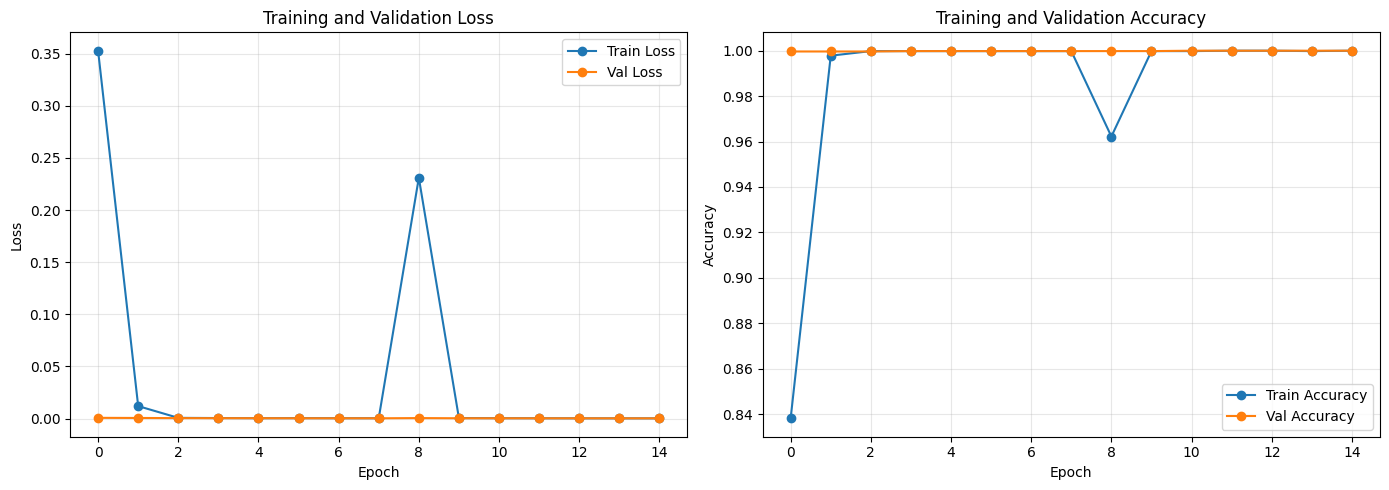

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Final evaluation on test set
test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

# Get class names
class_names = train_dataset.label_encoder.classes_

# Print results
print("="*60)
print("FINAL EVALUATION RESULTS")
print("="*60)
print(f"\nTest Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
print(f"Test Loss: {test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, zero_division=0))

FINAL EVALUATION RESULTS

Test Accuracy: 1.0000
Test Loss: 0.0002

Classification Report:
              precision    recall  f1-score   support

     aioquic       1.00      1.00      1.00      1375
       nginx       1.00      1.00      1.00      1496
      quicgo       1.00      1.00      1.00      1500
      quiche       1.00      1.00      1.00      1585

    accuracy                           1.00      5956
   macro avg       1.00      1.00      1.00      5956
weighted avg       1.00      1.00      1.00      5956



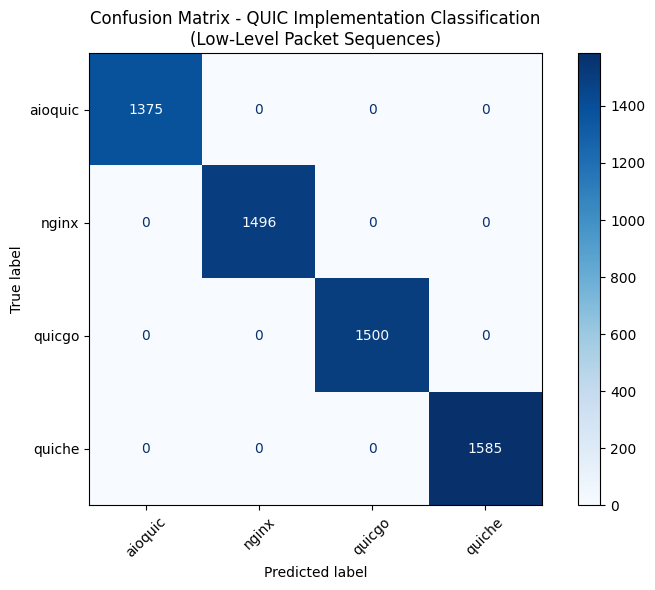

In [17]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", ax=ax, values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix - QUIC Implementation Classification\n(Low-Level Packet Sequences)")
plt.tight_layout()
plt.show()

In [18]:
# Per-class accuracy
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    mask = test_labels == i
    if mask.sum() > 0:
        class_acc = (test_preds[mask] == test_labels[mask]).mean()
        print(f"  {class_name}: {class_acc:.4f} ({mask.sum()} samples)")


Per-Class Accuracy:
  aioquic: 1.0000 (1375 samples)
  nginx: 1.0000 (1496 samples)
  quicgo: 1.0000 (1500 samples)
  quiche: 1.0000 (1585 samples)


## 8. TSTR Evaluation Function

This function can be used later to evaluate synthetic data quality by:
1. Training on synthetic data
2. Testing on real data
3. Comparing accuracy to Train Real Test Real (TRTR) baseline

In [29]:
def evaluate_tstr(synthetic_low_level_df, real_low_level_df, id_to_implementation, 
                  synthetic_ids, real_test_ids, device, epochs=15):
    """
    Train Synthetic Test Real (TSTR) evaluation.
    
    Args:
        synthetic_low_level_df: DataFrame with synthetic low-level data
        real_low_level_df: DataFrame with real low-level data
        id_to_implementation: Mapping from capture_id to implementation
        synthetic_ids: List of capture_ids for synthetic training data
        real_test_ids: List of capture_ids for real test data
        device: torch device
        epochs: Number of training epochs
    
    Returns:
        accuracy: Test accuracy on real data
        predictions: Model predictions
        true_labels: True labels
    """
    # Create synthetic training dataset
    train_dataset = LowLevelSequenceDataset(
        low_level_df=synthetic_low_level_df,
        id_to_implementation=id_to_implementation,
        capture_ids=synthetic_ids,
        scaler=None
    )
    
    # Create real test dataset (using scaler from synthetic)
    test_dataset = LowLevelSequenceDataset(
        low_level_df=real_low_level_df,
        id_to_implementation=id_to_implementation,
        capture_ids=real_test_ids,
        scaler=train_dataset.scaler
    )
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    
    # Initialize model
    model = LSTMClassifier(
        input_dim=len(train_dataset.feature_columns),
        hidden_dim=64,
        num_layers=2,
        num_classes=4,
        dropout=0.3
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    model, _ = train_model(model, train_loader, test_loader, optimizer, criterion, device, epochs=epochs)
    
    # Evaluate
    _, predictions, true_labels = evaluate(model, test_loader, criterion, device)
    accuracy = accuracy_score(true_labels, predictions)
    
    return accuracy, predictions, true_labels, train_dataset.label_encoder

In [30]:
# Get all capture IDs with their implementations
all_capture_ids = list(valid_capture_ids)
all_labels = [id_to_implementation[cid] for cid in all_capture_ids]


## Summary

This notebook provides:

1. **Data Loading**: Reads low-level packet sequences and maps them to implementation labels from high-level data
2. **Dataset Class**: `LowLevelSequenceDataset` handles variable-length sequences with proper scaling
3. **Model**: Bidirectional LSTM with attention for sequence classification
4. **Training Pipeline**: Complete training loop with validation
5. **TSTR Function**: Ready to use for synthetic data evaluation

### Next Steps for TSTR Evaluation:
1. Generate synthetic low-level data using WGAN or other models
2. Use `evaluate_tstr()` function with synthetic data for training
3. Compare accuracy against the TRTR baseline established here